# Figure 1: Desription of Genomic Composition

- Stacked/conjoined bar plots per sample type
- PCA with CST and location mapped
- Zicoseq with differentially abundant taxa between bodysites

In [177]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import random
import matplotlib.patches as mpatches
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from scipy.spatial import distance


In [178]:
#some global color schemes
my_cst_cmap = matplotlib.colors.ListedColormap(['#fe0308', '#86c61f','#ff7200','#448a73','#221886','#fae50d'])
my_timepoint_cmap = matplotlib.colors.ListedColormap(['#4d4f4e','#c2c4c2'])
my_cv_cmap = matplotlib.colors.ListedColormap(['#5924ed','#9fafe0'])

bodysite_colors = {
    'C':'#5924ed',
    'V': '#9fafe0'
}

cst_colors = {
    'I':'#fe0308',
    'II':'#86c61f',
    'III':'#ff7200',
    'IV-A':'#448a73',
    'IV-B':'#221886',
    'IV-C':'#989898',
    'V':'#fae50d'
}

#set up taxa color scheme
taxa_key = pd.read_csv('./common/VIRGO2_taxaKey.csv')
taxa_color_scheme = dict(zip(taxa_key.Taxa,taxa_key.Color))
taxa_text_legend = dict(zip(taxa_key.Taxa,taxa_key.Text))

def get_color(taxa):

    chars = '0123456789ABCDEF'

    if taxa in taxa_color_scheme:
        
        taxa_color = taxa_color_scheme[taxa]

    else:
        taxa_color_scheme[taxa] = '#'+''.join(random.sample(chars,6))
        taxa_color = taxa_color_scheme[taxa]

    return taxa_color



## Make the figure layout

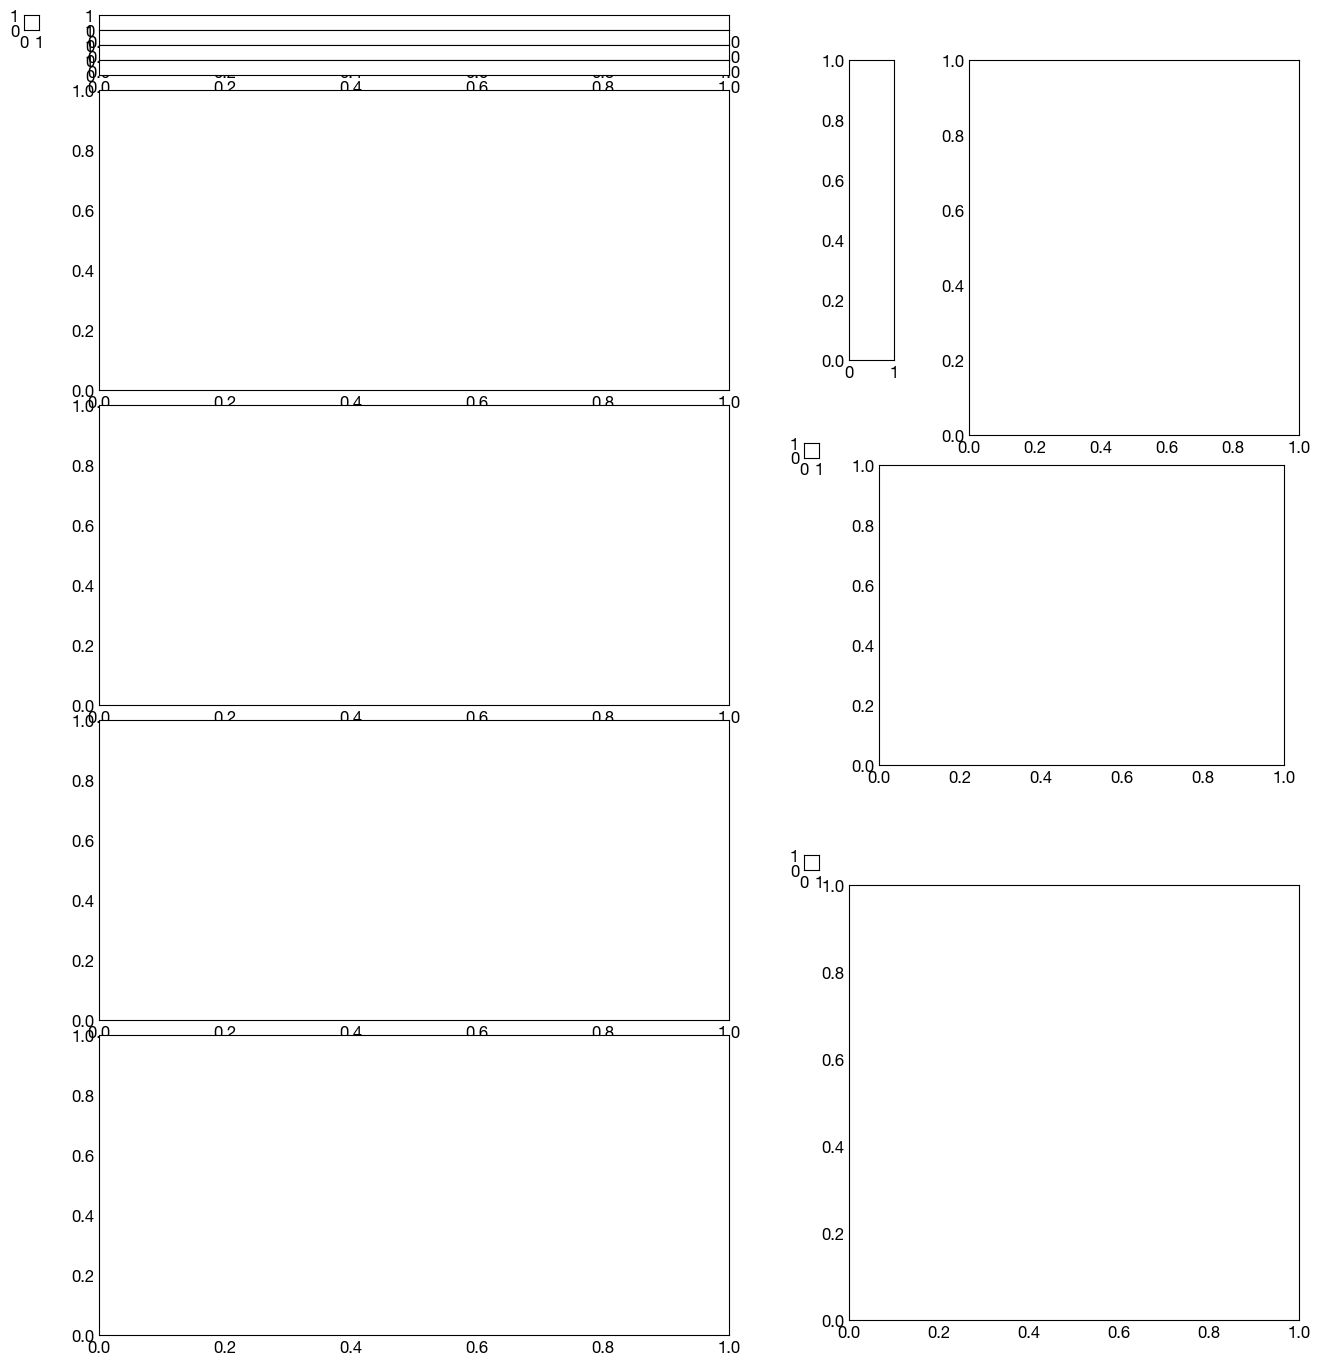

In [179]:
# figure size
WIDTH = 15
HEIGHT = 15

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))


### add the axes

# stacked bar plots

ax1_cst_c1 = fig.add_axes([0.05, 0.87, 0.42, 0.01])
ax1_cst_v1 = fig.add_axes([0.05, 0.86, 0.42, 0.01], sharex=ax1_cst_c1)
ax1_cst_c2 = fig.add_axes([0.05, 0.85, 0.42, 0.01], sharex=ax1_cst_c1)
ax1_cst_v2 = fig.add_axes([0.05, 0.84, 0.42, 0.01], sharex=ax1_cst_c1)


ax1_c1 = fig.add_axes([0.05, 0.63, 0.42, 0.2]) 
ax1_v1 = fig.add_axes([0.05, 0.42, 0.42, 0.2], sharex=ax1_cst_c1) 
ax1_c2 = fig.add_axes([0.05, 0.21, 0.42, 0.2], sharex=ax1_cst_c1) 
ax1_v2 = fig.add_axes([0.05, 0, 0.42, 0.2], sharex=ax1_cst_c1) 

# pcas
ax3 = fig.add_axes([0.57, 0.38, 0.27, 0.20])

# zicoseq
ax4 = fig.add_axes([0.55, 0.01, 0.3, 0.29])

# color bar legends
cbar_ax_cst = fig.add_axes([0.55, 0.65, 0.03, 0.20])

# axes to hold the taxa colors 
taxa_legend_ax = fig.add_axes([0.63, 0.60, 0.22, 0.25])

# axes for the figure labels
a_ax = fig.add_axes([0, 0.87, 0.01, 0.01])
b_ax = fig.add_axes([0.52, 0.585, 0.01, 0.01])
c_ax = fig.add_axes([0.52, 0.31, 0.01, 0.01])

## Stacked bar plot and all legends

In [180]:
#read in cleaned up virgo2 taxonomic relative abundance csv
data = pd.read_csv('./fig1_datasets/taxa_filt_mmtm_mg_virgo2_plotting.csv')

#read in the patient location file
pt_locs = pd.read_csv('./fig1_datasets/patient_locs.csv')

#concat the cervix/vagina and timepoint metadata
metadata = pd.read_csv('./common/mmtm_metadata.csv')
data = pd.merge(data, metadata, left_on='Sample', right_on='IGS LABEL', how='left')

#set the sample type
data['sample_type'] = data['Cervix/Vagina'].astype(str) + data['Timepoint'].astype(str)

# merge pt_locs with data
data = pd.merge(data, pt_locs, left_on='Ext Participant ID', right_on='pt_id', how='left')

# break the data df into a df per sample type
c1_data = data[data['sample_type'] == 'C1']
v1_data = data[data['sample_type'] == 'V1']
c2_data = data[data['sample_type'] == 'C2']
v2_data = data[data['sample_type'] == 'V2']

In [181]:
keep_columns = list(taxa_key['Taxa'])[:-1]
keep_columns.remove('BVAB2')
keep_columns.remove('other')
bar_width = 1
legend_entries = {}

cst_axes = [ax1_cst_c1, ax1_cst_v1, ax1_cst_c2, ax1_cst_v2]
bar_axes = [ax1_c1, ax1_v1, ax1_c2, ax1_v2]
labels = ['Cervix\nTimepoint 1', 'Vagina\nTimepoint 1', 'Cervix\nTimepoint 2', 'Vagina\nTimepoint 2']

for st_data in [c1_data, v1_data, c2_data, v2_data]:
    cst_ax = cst_axes.pop(0)
    barplot_ax = bar_axes.pop(0)

    # plotting the CST information
    for i, row in st_data.iterrows():
        cst_ax.bar(x=row['pt_loc'], height=1, width=bar_width, color=cst_colors[row['CST']], clip_on=False)
    cst_ax.set_xlim([0.5, 60.5])
    cst_ax.axis('off')

    # plotting the comps
    data_micro = st_data[keep_columns]

    data_micro['other'] = data_micro.apply(lambda row: 1.0 - row.sum(), axis=1)

    #data_sub = pd.concat([data[data.columns[0:9]], data_micro],axis=1,sort=False)
    data_sub = data[['Sample', 'pt_loc', 'CST', 'Cervix/Vagina', 'Timepoint']]
    data_sub = pd.concat([data_sub, data_micro], axis=1, sort=False)
    data_sub['bottom_count'] = pd.Series([0.0 for x in range(len(data_sub.index))], index=data_sub.index)

    for taxa in data_sub.columns[5:-1]:

        taxa_color = get_color(taxa)

        if taxa not in legend_entries:

            legend_entries[taxa] = taxa_color_scheme[taxa]
        
        barplot_ax.bar(x=data_sub['pt_loc'],height=data_sub[taxa],width=bar_width,bottom=data_sub['bottom_count'],color=taxa_color,clip_on=False)
        data_sub['bottom_count'] = data_sub['bottom_count'] + data_sub[taxa]

    barplot_ax.set_xlim([0.5,60.5])
    barplot_ax.set_ylim([0,1])
    barplot_ax.set_xticklabels([])
    barplot_ax.set_ylabel(labels.pop(0))

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_3378/628029061.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_micro['other'] = data_micro.apply(lambda row: 1.0 - row.sum(), axis=1)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_3378/628029061.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_micro['other'] = data_micro.apply(lambda row: 1.0 - row.sum(), axis=1)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_3378/628029061.py:24: SettingWithCopyWarning: 


In [182]:
# add the taxa legend
patch_list = []
for taxa in legend_entries:
    taxa_text = taxa_text_legend[taxa]

    if taxa_text == "BVAB1" or taxa_text == "Other":
        data_key = mpatches.Patch(color=legend_entries[taxa],label="%s" %(taxa_text))
    
    else:    
        data_key = mpatches.Patch(color=legend_entries[taxa],label="$\it{%s}$" %(taxa_text))
    
    patch_list.append(data_key)

taxa_legend_ax.legend(handles=patch_list,loc=[0,0],ncol=2, fontsize=9, frameon=False)
taxa_legend_ax.set_axis_off()

# adding all other colorbar legemds
#pt_cbarCV = matplotlib.colorbar.ColorbarBase(cbar_ax_bodysite, cmap=my_cv_cmap, orientation = 'vertical',ticklocation='right',ticks=[0.25,0.75])
#pt_cbarCV.ax.set_yticklabels(['Cervix','Vagina'],fontsize=8)
#cbar_ax_bodysite.set_ylim(1,0)
#cbar_ax_bodysite.text(0.45,-0.3,r"Body Site",fontsize=12,va='center',ha='center')

pt_cbarCST = matplotlib.colorbar.ColorbarBase(cbar_ax_cst, cmap=my_cst_cmap, orientation = 'vertical',ticklocation='right',ticks=[0.08,0.24,0.42,0.57,0.75,0.90])
pt_cbarCST.ax.set_yticklabels(['I', 'II', 'III', 'IV-A', 'IV-B', 'V'],fontsize=15)
cbar_ax_cst.set_ylim(1,0)
cbar_ax_cst.text(0.1,-0.025,r"CST",fontsize=15)

Text(0.1, -0.025, 'CST')

## Beta-diversity plots

In [183]:
## accessory functions
def get_mapping_results_by_patient(patient_id, rank_cutoff=20):
    '''
    Parses through the mapping results for the results of the samples taken from the specified patient.

    Parameters
    ----------
    patient_id: int
        a numerical value, without leading zeros, that IDs the patient of interest. 
    rank_cutoff: int
        taxanomies that fall below this rank will be set to 0.
        if set to -1, taxonomies will not be modified.

    Returns
    -------
    patient_info: dictionary
        A dictionary in the form: patient_info = {'c1':c1_info, 'v1':v1_info, 'c2':c2_info, 'v2':v2_info}
        If a sample is missing, it will be None
    '''
    
    #parse through the metadata to find the IGS sample IDs corresponding to each sample from the patient  (MTMXXX)
    c1_id = None
    v1_id = None
    c2_id = None
    v2_id = None

    try:
        c1_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'C') & (metadata['Timepoint'] == 1)]['IGS LABEL'].values[0])
    except:
        print('No c1_id for patient ' , patient_id)
        c1_id = None
    
   
    try:
        v1_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'V') & (metadata['Timepoint'] == 1)]['IGS LABEL'].values[0])
    except:
        print('No v1_id for patient ' , patient_id)
        v1_id = None

    
    try:
        c2_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'C') & (metadata['Timepoint'] == 2)]['IGS LABEL'].values[0])
    except:
        print('No c2_id for patient ' , patient_id)
        c2_id = None
    
    
    try:
        v2_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'V') & (metadata['Timepoint'] == 2)]['IGS LABEL'].values[0])
    except:
        print('No v2_id for patient ' , patient_id)
        v2_id = None


    c1_info = None
    v1_info = None
    c2_info = None
    v2_info= None
    
    c1_info = mapping_results[mapping_results['Taxa'] == c1_id]
    v1_info = mapping_results[mapping_results['Taxa'] == v1_id]
    c2_info = mapping_results[mapping_results['Taxa'] == c2_id]
    v2_info = mapping_results[mapping_results['Taxa'] == v2_id]
    patient_info = {'c1':c1_info, 'v1':v1_info, 'c2':c2_info, 'v2':v2_info}


    if rank_cutoff == -1:
        #patient_info = pd.concat(patient_info)
        return patient_info

    #set all taxa below the rank cutoff to 0
    rank_proc_patient_info = {'c1': None, 'v1':None, 'c2':None, 'v2':None}
    for sample, info in patient_info.items():
        if len(info) > 0:
            info_cutoff = sorted(info.values[0][1:], reverse=True)[rank_cutoff - 1]
            info_nums = info._get_numeric_data()
            info_nums[info_nums < info_cutoff] = 0

            #add in the "other" value to bring total to 1
            other_taxa_abdundance = 1 - sum(info_nums.values[0])
            info['other'] = [other_taxa_abdundance]
            

            rank_proc_patient_info[sample] = info
        


    patient_info = rank_proc_patient_info
    return patient_info


pt_sample_metadata_file = './common/mmtm_metadata.csv'
metadata = pd.read_csv(pt_sample_metadata_file)

def get_patient_samples(patient_id):
    '''
    Parses through the metadata and returns the sample ids associated with eac patient.

    Parameters
    ----------
    patient_id: int
        a numerical value, without leading zeros, that IDs the patient of interest. 

    Returns
    -------
    patient_samples: dictionary
        A dictionary in the form: patient_info = 
        'c1':c1_id,
        'v1':v1_id,
        'c2':c2_id,
        'v2':v2_id
        
        If a sample is missing, it will be None
    '''
    
    #parse through the metadata to find the IGS sample IDs corresponding to each sample from the patient  (MTMXXX)
    c1_id = None
    v1_id = None
    c2_id = None
    v2_id = None

    try:
        c1_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'C') & (metadata['Timepoint'] == 1)]['IGS LABEL'].values[0])
    except:
        print('No c1_id for patient ' , patient_id)
        c1_id = None
    
   
    try:
        v1_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'V') & (metadata['Timepoint'] == 1)]['IGS LABEL'].values[0])
    except:
        print('No v1_id for patient ' , patient_id)
        v1_id = None

    
    try:
        c2_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'C') & (metadata['Timepoint'] == 2)]['IGS LABEL'].values[0])
    except:
        print('No c2_id for patient ' , patient_id)
        c2_id = None
    
    
    try:
        v2_id = str(metadata[(metadata['Ext Participant ID'] == patient_id) & (metadata['Cervix/Vagina'] == 'V') & (metadata['Timepoint'] == 2)]['IGS LABEL'].values[0])
    except:
        print('No v2_id for patient ' , patient_id)
        v2_id = None

    #return {c1_id: 'c1',
    #        v1_id: 'v1',
    #        c2_id: 'c2',
    #        v2_id: 'v2'}

    return {
        'c1':c1_id,
        'v1':v1_id,
        'c2':c2_id,
        'v2':v2_id
    }


def parse_data(data):
    ''' 
    Gets the numerical values from a specific sample dataframe.

    Parameter
    ---------
    data: df

    Returns
    -------
    n_data: list
        Numerical data
    '''

    n_data = list(data.values[0])[1:]
    return n_data


def process_patient(pid, bdiversity_approach):
    ''' 
    Calculate all relevant diversity metrics for a specific patient: C1<->V1, C2<->V2, C1<->C2, V1<->V2
    Uses the distance approach specified. 

    Parameters
    ----------
    pid: int
        The patient of interest
    bdiversity_approach: function
        The distance function to use to compare the two communities of interest. 
    
    Returns
    -------
    metrics: dictionary with the metrics between C1<->V1, C2<->V2, C1<->C2, and V1<->V2. If any of the samples are missing, the value will be NaN
        {
            c1_v1:float,
            c2_v2:float,
            c1_c2:float,
            v1_v2:float,
            c1_v2:float,
            c2_v1:float
        }
    '''

    metrics = {
        'c1_v1': np.NaN,
        'c2_v2': np.NaN,
        'c1_c2': np.NaN,
        'v1_v2': np.NaN,
        'c1_v2': np.NaN,
        'c2_v1': np.NaN

    }

    #fetch the patient data
    pt_info = get_mapping_results_by_patient(patient_id=pid, rank_cutoff=-1)

    try:
        metrics['c1_v1'] = bdiversity_approach(parse_data(pt_info['c1']), parse_data(pt_info['v1']))
    except:
        pass
    
    try:
        metrics['c2_v2'] = bdiversity_approach(parse_data(pt_info['c2']), parse_data(pt_info['v2']))
    except:
        pass
    
    try:
        metrics['c1_c2'] = bdiversity_approach(parse_data(pt_info['c1']), parse_data(pt_info['c2']))
    except:
        pass

    try:
        metrics['v1_v2'] = bdiversity_approach(parse_data(pt_info['v1']), parse_data(pt_info['v2']))
    except:
       pass

    try:
        metrics['c1_v2'] = bdiversity_approach(parse_data(pt_info['c1']), parse_data(pt_info['v2']))
    except:
       pass
    
    try:
        metrics['c2_v1'] = bdiversity_approach(parse_data(pt_info['c2']), parse_data(pt_info['v1']))
    except:
       pass


    return metrics   

In [184]:
# read in data
mapping_results = pd.read_csv('./common/taxa_filt_mmtm_mg_virgo2.csv')
mapping_results = mapping_results.set_index('Taxa').T
mapping_results = mapping_results.reset_index()
mapping_results = mapping_results.rename(columns={'index': 'Taxa'})
mapping_results = mapping_results.rename_axis(None, axis=1)

static_cols = mapping_results.columns[0:2].to_list()
sorted_cols = np.sort(mapping_results.columns.difference(static_cols)).tolist()
mapping_results = mapping_results.loc[:, static_cols+sorted_cols]

#read in the metadata and parse out the list of patient ids
metadata = pd.read_csv('./common/mmtm_metadata.csv')
patient_ids = list(metadata['Ext Participant ID'].unique())

sample_csts = pd.read_csv('./common/mmtm_cst_assignments_taxa_corr.csv')

In [185]:
# calculate beta-diversity 
bdiversity_metrics = {'jensenshannon':distance.jensenshannon}
all_metrics = {}
for div_met, div_func in bdiversity_metrics.items():
    all_metrics[div_met] = None
    #a dataframe holding all data for this diversity metric
    curr_metric_data = {
        'pid':[],
        'c1_v1': [],
        'c2_v2': [],
        'c1_c2': [],
        'v1_v2': [],
        'c1_v2':[],
        'c2_v1':[]
    }

    #iterate through each patient and make a dataframe holding the info for this metric for all patients
    for pid in patient_ids:
        pt_metrics = process_patient(pid=pid, bdiversity_approach=div_func)
        pt_metrics['pid'] = pid

        for m in curr_metric_data.keys():
            curr_metric_data[m].append(pt_metrics[m])
    
    curr_metric_data = pd.DataFrame(curr_metric_data)
    all_metrics[div_met] = curr_metric_data

bdiv_to_plot = all_metrics['jensenshannon']

In [186]:
bdiv_to_plot['loc_avg'] = np.mean(bdiv_to_plot[['c1_v1', 'c2_v2']], axis=1)
bdiv_to_plot['tp_avg'] = np.mean(bdiv_to_plot[['c1_c2', 'v1_v2']], axis=1)
bdiv_to_plot = bdiv_to_plot[['loc_avg', 'tp_avg']].melt(var_name='Compare Type', value_name='bdiv').dropna()

In [187]:
# plot
sns.boxplot(x=bdiv_to_plot['Compare Type'], y=bdiv_to_plot['bdiv'], ax=ax3, color='#ebe9e6', showfliers=False, width=0.3, notch=True)
sns.stripplot(x=bdiv_to_plot['Compare Type'], y=bdiv_to_plot['bdiv'], ax=ax3, edgecolor='black', color="black", size=3, linewidth=1)

#sns.scatterplot(data=mg_pca, x=0, y=1, ax=ax3, hue='location', palette=bodysite_colors, s=30, legend=False, edgecolor='black')

ax3.set_ylabel('β-diversity (JSD)', fontsize=15)
ax3.set_xticklabels(['Between\nBody Sites', 'Over\nTime'], fontsize=15)
ax3.set_xlabel('')



/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_3378/1393114212.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_xticklabels(['Between\nBody Sites', 'Over\nTime'], fontsize=15)


Text(0.5, 574.4444444444445, '')

## Zicoseq: taxa between bodysites

In [188]:
#open the zicoseq results
zseq_results = pd.read_csv('./fig1_datasets/mmtm_mg_taxa_cv_zicoseq_results.csv')
zseq_results.rename(columns={'Unnamed: 0': 'id'}, inplace=True)

#get the -log10 of the p value
zseq_results['-log10_p.adj.fdr'] = -1 * np.log10(zseq_results['p.adj.fdr'])

#adjust the sign of R2
zseq_results['signed_R2'] = zseq_results['R2'] * (zseq_results['Cervix.VaginaV']/abs(zseq_results['Cervix.VaginaV']))

#col for the color of the points
zseq_results['sig'] = zseq_results['p.adj.fdr'] <= 0.05
zseq_results['is_corny'] = zseq_results['id'].str.contains('Corynebacterium')

conditions = [
    (zseq_results['sig'] == False),
    (zseq_results['sig'] == True) & (zseq_results['is_corny'] == False),
    (zseq_results['sig'] == True) & (zseq_results['is_corny'] == True)
]

choices = [0, 1, 2]
zseq_results['color_annot'] = np.select(conditions, choices)

sns.scatterplot(data=zseq_results, x='signed_R2', y='-log10_p.adj.fdr', s=50, hue='color_annot', palette={0:'#b5b3b3', 1:'#333232', 2:'#259453'}, ax=ax4, edgecolor='black')

ax4.set_title('Cervix vs Vagina: Differentially Abundant Taxa', fontsize=15)
ax4.set_xlabel('R' + "$^%s$" % ('2'),fontsize=15)
ax4.set_ylabel(r'-log$_{10}$'+ '(' + r'p$_{adj}$' + ')',fontsize=15)
ax4.set_xbound((-0.02, 0.04))
ax4.set_ybound((0,3))
ax4.get_legend().remove()
ax4.axvline(x=0, color='black', linestyle='--', linewidth=0.5)

handles, labels  =  ax4.get_legend_handles_labels()
handles.reverse()
for h in handles:
    h._sizes = [75]
ax4.legend(handles, ["$\it{%s}$" %('Corynebacterium') + ' sp.', 'Non-' + "$\it{%s}$" %('Corynebacterium') + ' sp.', 'FDR > 0.05'], loc='lower right', fontsize=8)
ax4.text(x=-0.02, y=2.75, s=' ↑Cervix', fontsize=18, ha='left', fontfamily='Arial')
ax4.text(x=0.04, y=2.75, s='↑Vagina ', fontsize=18, ha='right', fontfamily='Arial')


Text(0.04, 2.75, '↑Vagina ')

## Add Figure Labels

In [189]:
#a_ax.text(x=0,y=0,s='A', fontsize=18)
#b_ax.text(x=0,y=0,s='B', fontsize=18)
#c_ax.text(x=0,y=0,s='C', fontsize=18)
#d_ax.text(x=0,y=0,s='D', fontsize=18)

labels = ['A', 'B', 'C']
for ax in [a_ax, b_ax, c_ax]:
    ax.text(x=0,y=0,s=labels.pop(0),fontsize=24, weight='bold')
    ax.set_axis_off()

## Save Figure

In [190]:
fig.savefig('fig1_V3.pdf', format='pdf', bbox_inches='tight')
plt.show()

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
